# 🌧️ บทที่ 08 — QPE: การประมาณปริมาณฝนจากเรดาร์
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นสูง  |  **ต้องมีก่อน:** รันบทที่ 00 แล้ว (ใช้แนวคิด Z–R จากบท 01 และ gate filter จากบท 03)

**วัตถุประสงค์การเรียนรู้**
- แปลง reflectivity (dBZ) เป็น **อัตราฝน R (mm/hr)** ด้วยสูตร Z–R หลายแบบ
- คำนวณ **ฝนสะสม** ช่วงเวลา 10:00–10:30 UTC
- เปรียบเทียบผลของสูตร **Marshall–Palmer vs Rosenfeld (เขตร้อน)** เชิงพื้นที่
- สรุป **สถิติเชิงพื้นที่** (ค่าเฉลี่ย/สูงสุด/พื้นที่ฝนเกินเกณฑ์) และเข้าใจความไม่แน่นอนของ QPE

---


## 🧠 หลักการเบื้องต้น

**QPE (Quantitative Precipitation Estimation)** คือการประมาณปริมาณฝนจากค่าที่เรดาร์วัดได้

วิธีพื้นฐานคือ **R(Z)** — ใช้ความสัมพันธ์ Z–R (บท 01): แปลง `dBZ → z → R = (z/a)^{1/b}` โดยเลือกสูตรตามชนิดฝน (ไทยเป็นเขตร้อน มักเหมาะกับ Rosenfeld)

**ฝนสะสม (accumulation)** — อัตราฝน R มีหน่วย mm/hr เมื่อคูณด้วยช่วงเวลาจะได้ความลึกฝน (mm) เรามีข้อมูล 2 ช่วงเวลาห่างกัน 30 นาที จึงประมาณฝนสะสมแบบ trapezoidal:

$$P \;=\; \frac{R_{10:00} + R_{10:30}}{2}\times 0.5\ \text{hr}$$

**ข้อจำกัด/ความไม่แน่นอนของ QPE:** การเลือกสูตร Z–R, การปรับแก้ attenuation (บท 07), การมีเพียง 2 ภาพถ่าย (ไม่ได้คิดการเคลื่อนตัวของฝนระหว่างช่วง), ความสูงลำบีม ฯลฯ

> **วิธี polarimetric (R(KDP), R(Z,ZDR))** ให้ผลแม่นกว่าในฝนหนัก แต่ต้องประมาณ KDP ก่อน ซึ่งอยู่ในบทที่ 07 — บทนี้เน้น **R(Z)** ที่ต่อยอดจากบท 01 โดยตรง


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive + ฟอนต์ไทย)


In [ ]:
%pip install -q arm_pyart geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 67.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyart, geopandas as gpd
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/tmd_radar_course'
sys.path.append(os.path.join(ROOT, '9config'))
import course_paths as P
assert os.path.exists(P.RADAR_1000) and os.path.exists(P.RADAR_1030), \
       "⚠️ ไม่พบข้อมูลเรดาร์ — กรุณารัน Notebook 00 ก่อน"
OUT = P.results_dir('lesson08')
print("พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่:", OUT)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson08


### 🔤 ติดตั้งฟอนต์ไทยสำหรับกราฟ (จำเป็น — มิฉะนั้นข้อความไทยจะแสดงเป็นกล่อง □□□)

ดาวน์โหลดฟอนต์ **Sarabun** (ฟอนต์ราชการไทย เหมาะงานตีพิมพ์) มาลงทะเบียนกับ matplotlib พร้อมตั้งสไตล์กราฟระดับตีพิมพ์ — รันเซลล์นี้ก่อนพลอตทุกครั้ง

In [ ]:
# ── ติดตั้ง & ตั้งค่าฟอนต์ไทยให้ matplotlib (ต้องรันก่อนพลอตกราฟที่มีข้อความไทย) ──
import os, glob, subprocess, urllib.request
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.font_manager as fm

def setup_thai_font(verbose=True):
    d = '/usr/share/fonts/truetype/sarabun'; os.makedirs(d, exist_ok=True)
    # 1) Sarabun จาก Google Fonts (ฟอนต์ราชการไทย)
    if not glob.glob(d + '/*.ttf'):
        base = 'https://github.com/google/fonts/raw/main/ofl/sarabun/'
        for fn in ('Sarabun-Regular.ttf', 'Sarabun-Bold.ttf'):
            try: urllib.request.urlretrieve(base + fn, os.path.join(d, fn))
            except Exception: pass
    # 2) สำรอง: ฟอนต์ไทย TLWG ผ่าน apt (มีใน Colab เสมอ)
    if not glob.glob(d + '/*.ttf') and not glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-thai-tlwg'], capture_output=True)
    # ลงทะเบียนฟอนต์ที่ติดตั้ง
    for fp in glob.glob(d + '/*.ttf') + glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        try: fm.fontManager.addfont(fp)
        except Exception: pass
    avail = {f.name for f in fm.fontManager.ttflist}
    chosen = next((n for n in ('Sarabun','Loma','Garuda','Norasi') if n in avail), None)
    if chosen: mpl.rcParams['font.family'] = chosen
    mpl.rcParams['axes.unicode_minus'] = False
    if verbose:
        print('ฟอนต์ไทยที่ใช้:', chosen or 'ไม่พบ — ลองรันเซลล์นี้อีกครั้งหลังติดตั้ง')
    return chosen

setup_thai_font()
# สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย)
plt.rcParams.update({'figure.dpi':120, 'savefig.dpi':300, 'font.size':13,
    'axes.titlesize':16, 'axes.labelsize':14, 'xtick.labelsize':12,
    'ytick.labelsize':12, 'legend.fontsize':13, 'axes.unicode_minus':False})

ฟอนต์ไทยที่ใช้: Sarabun


## 1️⃣ สร้าง CAPPI 2 กม. ของทั้งสองช่วงเวลา

ทำ gate filter (บท 03) แล้ว grid เป็น CAPPI บนกริดเดียวกัน เพื่อให้อาร์เรย์ตรงกันสำหรับคำนวณฝนสะสม


In [ ]:
def grid_cappi(path, z_m=2000.0, n=481, half=240000.0, field='reflectivity'):
    "อ่านไฟล์เรดาร์ → กรองคุณภาพ → สร้าง CAPPI คืน dBZ 2 มิติ + พิกัด lon/lat"
    r = pyart.io.read(path)
    gf = pyart.filters.GateFilter(r)
    gf.exclude_below('cross_correlation_ratio', 0.80)
    gf.exclude_below('reflectivity', 0.0)
    g = pyart.map.grid_from_radars(
        (r,), gatefilters=(gf,),
        grid_shape=(1, n, n),
        grid_limits=((z_m, z_m), (-half, half), (-half, half)),
        fields=[field], weighting_function='Barnes2')
    dbz = np.ma.filled(g.fields[field]['data'][0], np.nan)
    lons, lats = g.get_point_longitude_latitude(level=0)
    return dbz, lons, lats

dbz_1000, lons, lats = grid_cappi(P.RADAR_1000)
dbz_1030, _, _       = grid_cappi(P.RADAR_1030)
print("สร้าง CAPPI ทั้งสองช่วงเวลาแล้ว ✅  ขนาดกริด:", dbz_1000.shape)

# ขอบเขตจังหวัดสำหรับซ้อนแผนที่
prov = gpd.read_file(P.PROVINCE_SHP)
if prov.crs is None: prov = prov.set_crs('EPSG:4326')

สร้าง CAPPI ทั้งสองช่วงเวลาแล้ว ✅  ขนาดกริด: (481, 481)


## 2️⃣ แปลง dBZ → อัตราฝน R ด้วยสูตร Z–R หลายแบบ


In [ ]:
ZR = {
    'Marshall-Palmer': (200.0, 1.6),
    'Rosenfeld tropical': (250.0, 1.2),
    'Summer convection': (300.0, 1.4),
}

def dbz_to_R(dbz, a, b):
    "แปลง dBZ -> อัตราฝน R (mm/hr); ไม่มี echo = ไม่มีฝน (0)"
    R = (10.0 ** (dbz / 10.0) / a) ** (1.0 / b)
    return np.where(np.isfinite(R), R, 0.0)

# อัตราฝนที่ 10:00 ของแต่ละสูตร
R_1000 = {name: dbz_to_R(dbz_1000, a, b) for name, (a, b) in ZR.items()}
for name, R in R_1000.items():
    wet = R[R > 0.1]
    print(f"{name:20s}: ฝนสูงสุด {R.max():6.1f} mm/hr | เฉลี่ยเฉพาะพื้นที่ฝน {wet.mean():5.2f} mm/hr")

Marshall-Palmer     : ฝนสูงสุด  236.8 mm/hr | เฉลี่ยเฉพาะพื้นที่ฝน  2.22 mm/hr
Rosenfeld tropical  : ฝนสูงสุด 1216.3 mm/hr | เฉลี่ยเฉพาะพื้นที่ฝน  4.14 mm/hr
Summer convection   : ฝนสูงสุด  387.1 mm/hr | เฉลี่ยเฉพาะพื้นที่ฝน  2.26 mm/hr


## 3️⃣ แผนที่อัตราฝนเปรียบเทียบ 3 สูตร (เวลา 10:00 UTC)


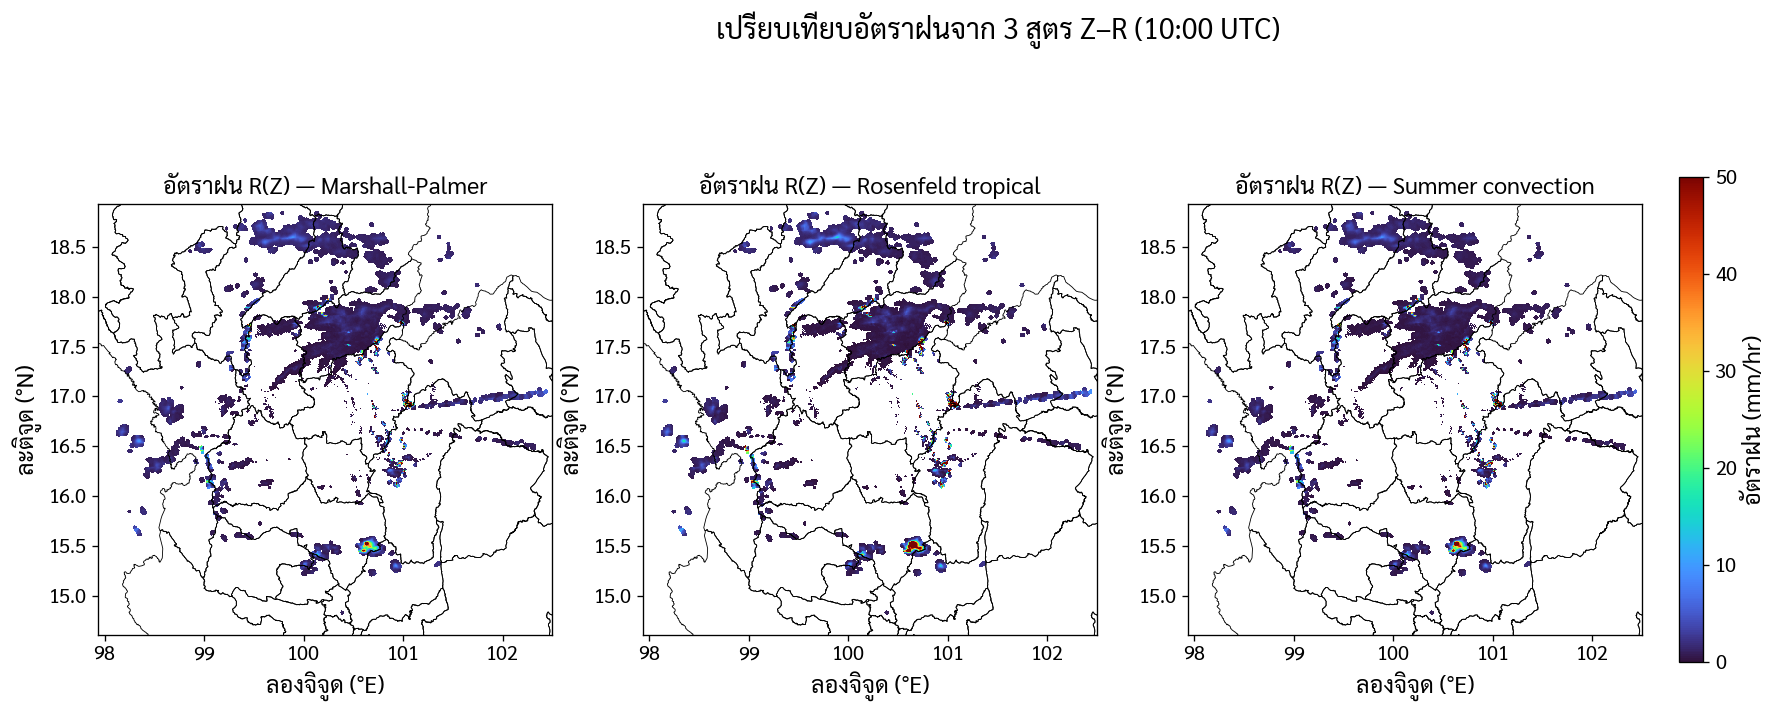

In [ ]:
def rain_map(ax, R, lons, lats, title, vmax=50):
    Rd = np.where(R < 0.1, np.nan, R)       # ไม่มีฝน = ขาว
    pm = ax.pcolormesh(lons, lats, Rd, cmap='turbo', vmin=0, vmax=vmax, shading='auto')
    prov.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
    ax.set_xlim(lons.min(), lons.max()); ax.set_ylim(lats.min(), lats.max())
    ax.set_aspect('equal'); ax.set_title(title, fontsize=14)
    ax.set_xlabel('ลองจิจูด (°E)'); ax.set_ylabel('ละติจูด (°N)')
    return pm

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (name, R) in zip(axes, R_1000.items()):
    pm = rain_map(ax, R, lons, lats, f'อัตราฝน R(Z) — {name}')
cb = fig.colorbar(pm, ax=axes, shrink=0.75, pad=0.02)
cb.set_label('อัตราฝน (mm/hr)', fontsize=14)
fig.suptitle('เปรียบเทียบอัตราฝนจาก 3 สูตร Z–R (10:00 UTC)', fontsize=17)
fig.savefig(os.path.join(OUT, 'rainrate_compare_ZR.png'), dpi=300, bbox_inches='tight')
plt.show()

**สังเกต:** ในแกนฝนหนัก (dBZ สูง) สูตร **Rosenfeld** ให้อัตราฝนมากกว่า Marshall–Palmer อย่างชัดเจน สอดคล้องกับบท 01 — การเลือกสูตรจึงมีผลต่อการประเมินฝนของไทยโดยตรง


## 4️⃣ ฝนสะสม 10:00–10:30 UTC (เทียบ MP vs Rosenfeld)


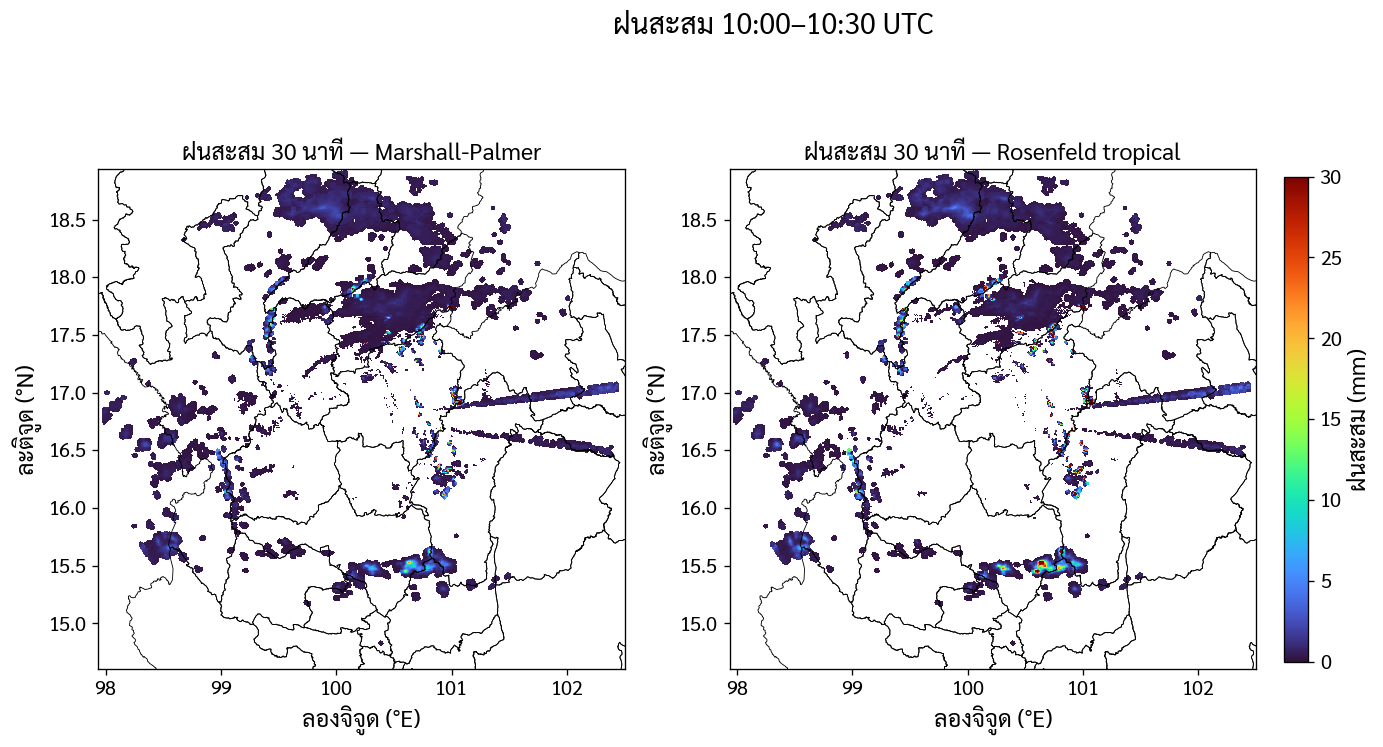

In [ ]:
interval_hr = 0.5  # ช่วงเวลา 30 นาที

def accumulate(a, b):
    "ฝนสะสม (mm) แบบ trapezoidal จากสองช่วงเวลา"
    R1 = dbz_to_R(dbz_1000, a, b)
    R2 = dbz_to_R(dbz_1030, a, b)
    return (R1 + R2) / 2.0 * interval_hr

acc = {name: accumulate(a, b) for name, (a, b) in ZR.items()}

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, name in zip(axes, ['Marshall-Palmer', 'Rosenfeld tropical']):
    pm = rain_map(ax, acc[name], lons, lats, f'ฝนสะสม 30 นาที — {name}', vmax=30)
cb = fig.colorbar(pm, ax=axes, shrink=0.75, pad=0.02)
cb.set_label('ฝนสะสม (mm)', fontsize=14)
fig.suptitle('ฝนสะสม 10:00–10:30 UTC', fontsize=17)
fig.savefig(os.path.join(OUT, 'rain_accumulation.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5️⃣ ตารางสถิติเชิงพื้นที่

กริด 1×1 กม. ดังนั้นจำนวนพิกเซล = พื้นที่ (กม.²) โดยตรง


In [ ]:
PIX_KM2 = 1.0
rows = []
for name, (a, b) in ZR.items():
    R = R_1000[name]; A = acc[name]
    wet = R[R > 0.1]
    rows.append({
        'สูตร Z–R': name,
        'ฝนสูงสุด (mm/hr)': round(float(R.max()), 1),
        'ฝนเฉลี่ยพื้นที่ฝน (mm/hr)': round(float(wet.mean()), 2),
        'พื้นที่ฝน>10mm/hr (กม².)': int(np.sum(R > 10) * PIX_KM2),
        'ฝนสะสมสูงสุด (mm)': round(float(A.max()), 1),
        'ฝนสะสมเฉลี่ยพื้นที่ฝน (mm)': round(float(A[A > 0.1].mean()), 2),
    })
stats = pd.DataFrame(rows)

# ผลต่างเทียบ Marshall-Palmer
base_area = stats.loc[stats['สูตร Z–R']=='Marshall-Palmer', 'พื้นที่ฝน>10mm/hr (กม².)'].values[0]
stats['ผลต่างพื้นที่ vs MP (%)'] = round((stats['พื้นที่ฝน>10mm/hr (กม².)'] - base_area) / base_area * 100, 1)
stats

,สูตร Z–R,ฝนสูงสุด (mm/hr),ฝนเฉลี่ยพื้นที่ฝน (mm/hr),พื้นที่ฝน>10mm/hr (กม².),ฝนสะสมสูงสุด (mm),ฝนสะสมเฉลี่ยพื้นที่ฝน (mm),ผลต่างพื้นที่ vs MP (%)
0,Marshall-Palmer,236.8,2.22,632,195.5,0.87,0.0
1,Rosenfeld tropical,1216.3,4.14,933,1237.9,1.81,47.6
2,Summer convection,387.1,2.26,652,348.7,0.96,3.2


## 📝 แบบฝึกหัด

1. **เขตร้อนควรใช้สูตรใด?** เทียบฝนสะสมของ Marshall–Palmer กับ Rosenfeld เชิงพื้นที่ — ต่างกันสูงสุดกี่ mm และคิดเป็นกี่ % ของพื้นที่ฝน?
2. เปลี่ยน **ระดับความสูง CAPPI** เป็น 1.5 กม. (ใกล้พื้นกว่า) แล้วดูว่าฝนประเมินได้ต่างจาก 2 กม. อย่างไร
3. สร้างสูตร Z–R ของคุณเอง (เลือก a,b) เพิ่มลงใน `ZR` แล้วรันสถิติใหม่
4. (ขั้นสูง) ลองใช้ `corrected_reflectivity` แทน `reflectivity` ใน `grid_cappi` แล้วเทียบผล (ปรับแก้ attenuation แล้วฝนควรมากขึ้นในแกนพายุ)


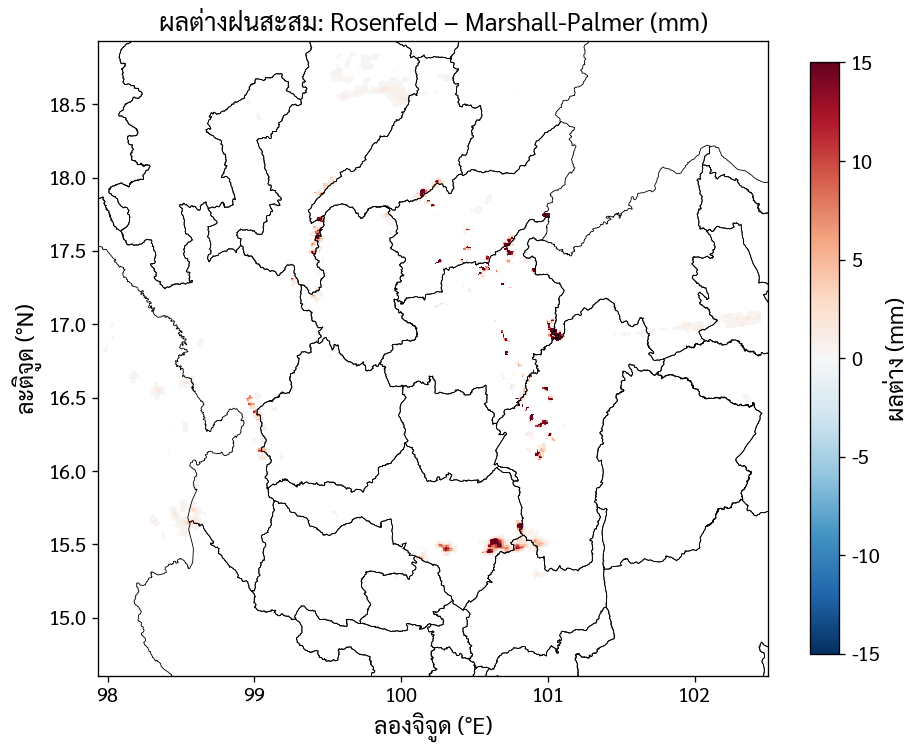

ผลต่างสูงสุด (Rosenfeld มากกว่า MP): 1042.4 mm


In [ ]:
# แบบฝึกหัดข้อ 1 (โครงเริ่มต้น): แผนที่ผลต่างฝนสะสม Rosenfeld - MP
diff = acc['Rosenfeld tropical'] - acc['Marshall-Palmer']
diff_disp = np.where(np.abs(diff) < 0.1, np.nan, diff)

fig, ax = plt.subplots(figsize=(9, 8))
pm = ax.pcolormesh(lons, lats, diff_disp, cmap='RdBu_r', vmin=-15, vmax=15, shading='auto')
prov.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
ax.set_xlim(lons.min(), lons.max()); ax.set_ylim(lats.min(), lats.max()); ax.set_aspect('equal')
ax.set_xlabel('ลองจิจูด (°E)'); ax.set_ylabel('ละติจูด (°N)')
ax.set_title('ผลต่างฝนสะสม: Rosenfeld − Marshall-Palmer (mm)', fontsize=15)
cb = plt.colorbar(pm, ax=ax, shrink=0.8); cb.set_label('ผลต่าง (mm)')
plt.show()
print("ผลต่างสูงสุด (Rosenfeld มากกว่า MP):", round(float(np.nanmax(diff)), 1), "mm")
# TODO (นิสิต): ทำข้อ 2–4 ต่อ

---
## 🎯 สรุป

- QPE พื้นฐานคือ **R(Z)** — เลือกสูตร Z–R ให้เหมาะกับชนิดฝน (ไทยเขตร้อน → Rosenfeld มักเหมาะกว่า)
- ฝนสะสมได้จากอัตราฝน × ช่วงเวลา (บทนี้ใช้ trapezoidal จาก 2 ภาพ)
- การเลือกสูตร Z–R ทำให้ปริมาณฝนและพื้นที่ฝนหนักต่างกันอย่างมีนัย — สำคัญต่อการใช้งานจริง
- วิธี polarimetric (R(KDP)) จะแม่นกว่าในฝนหนัก (บท 07)

**บทถัดไปที่เกี่ยวข้อง:** บท 12 (zonal statistics) จะนำฝนที่ประมาณได้นี้ไปสรุปรายลุ่มน้ำย่อย และเทียบสูตร Z–R ต่อพื้นที่ลุ่มน้ำ
